In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr
import pandas as pd
import numpy as np
import copy
from datetime import datetime, timedelta
grav=9.81

In [2]:
df_manobs = pd.read_csv('df_all_events_tw_29juillet2026.csv')
df_manobs['rounded_time'] = pd.to_datetime(df_manobs['rounded_time'] ) 

In [3]:
def plot_trajectory(fig,ax,df_for_plot,var_to_plot = 'manobs_with_mix'):
        
    # color_list = {'No precip.':'grey','PL':'#1f77b4','FZRA':'#2ca02c','FZRA and PL':'#ff7f0e'}
    # color_list = {'No precip.':'grey','PL':'#1f77b4','FZRA':"#ff0e0e",'FZRA and PL':'#2ca02c','RA':'k','SN and PL':'cyan','SN':'purple','RA and PL':'darkgreen'}
    # marker_list = {'None':'_','No precip.':'_',    'PL':'o'  ,'FZRA':'^','FZRA and PL':'s','SN and FZRA':'s','RA and PL':'darkorange','RA':'o','SN and PL':'o','SN':'o','RA and PL':'.'}
    color_list = {'SN and FZRA':'blue','SN and RA':'darkblue','None':'grey','No precip.':'grey','PL':'#1f77b4','FZRA':"#ff0e0e",'FZRA and PL':'#2ca02c','RA':'k','SN and PL':'cyan','SN':'cyan','RA and PL':'darkgreen'}
    marker_list = {'SN and FZRA':'s','SN and RA':'s','None':'_','No precip.':'_',    'PL':'o'  ,'FZRA':'^','FZRA and PL':'s','SN and FZRA':'s','RA and PL':'s','RA':'^','SN and PL':'o','SN':'o','RA and PL':'s'}
    # marker_list = {'SN and FZRA':'s','SN and RA':'s','None':'_','No precip.':'_',    'PL':'s'  ,'FZRA':'s','FZRA and PL':'s','SN and FZRA':'s','RA and PL':'s','RA':'s','SN and PL':'s','SN':'s','RA and PL':'s'}    
    
    
    facecolor_list = color_list
    grav=9.81
    
    
    df_for_plot = df_for_plot.dropna(how='all',subset =[var_to_plot])
    df_for_plot = df_for_plot[((df_for_plot.WL_integral>0.) & (df_for_plot.CL_integral<0.) )]#& (df_for_plot.first_temp<0.) 
    df_for_plot = df_for_plot.replace({'None':'No precip.'})
    df_for_plot = df_for_plot.sort_values(by='rounded_time')
    # Ajouter les points
    for type in  df_for_plot[var_to_plot].unique():
        
        if (type=='FZRA and PL'):
            markerfacecolor    = '#2ca02c'
            markerfacecoloralt = '#2ca02c'
            markeredgecolor    = '#2ca02c'
        elif ('and' in type):
            markerfacecolor    = color_list[type.split(' ')[0]]
            markerfacecoloralt = color_list[type.split(' ')[-1]]
            markeredgecolor = 'none'
        else:
            markerfacecolor    = color_list[type]
            markerfacecoloralt = color_list[type]
            markeredgecolor    = color_list[type]        
        
        
        df_for_plot_to_plot = df_for_plot[df_for_plot[var_to_plot]==type]
        scatter = ax.plot(
            df_for_plot_to_plot['WL_integral']*grav/273.15, -df_for_plot_to_plot['CL_integral']*grav/273.15,
            c=color_list[type], zorder =10 , markerfacecolor=markerfacecolor,markerfacecoloralt=markerfacecoloralt,marker=marker_list[type],fillstyle='left',linestyle='None',markeredgecolor=markeredgecolor)
    
    
    for type in  ['PL','FZRA','FZRA and PL','RA','SN and PL','SN','RA and PL']:
        if (type=='FZRA and PL'):
            markerfacecolor    = '#2ca02c'
            markerfacecoloralt = '#2ca02c'
            markeredgecolor    = '#2ca02c'
        elif ('and' in type):
            markerfacecolor    = color_list[type.split(' ')[0]]
            markerfacecoloralt = color_list[type.split(' ')[-1]]
            markeredgecolor = 'none'
        else:
            markerfacecolor    = color_list[type]
            markerfacecoloralt = color_list[type]
            markeredgecolor    = color_list[type]             
        scatter = ax.plot(
            -20, -20,
            c=color_list[type], zorder =10 , label=type, markerfacecolor=markerfacecolor,markerfacecoloralt=markerfacecoloralt,marker=marker_list[type],fillstyle='left',linestyle='None',markeredgecolor=markeredgecolor)
        
        
        
        
    x,y = df_for_plot['WL_integral'].values*grav/273.15, -df_for_plot['CL_integral'].values*grav/273.15
    ax.plot(x, y, color='k', zorder =1,linewidth=1)

    # Add arrow at the end of the curve
    distance_last_two_points = np.sqrt((y[-1]-y[-2])**2 + (x[-1]-x[-2])**2 )
    ax.annotate(
        '', 
        xy=(x[-1]+50*(x[-1]-x[-2])/distance_last_two_points, y[-1]+50*(y[-1]-y[-2])/distance_last_two_points),        # arrow tip (end)
        xytext=(x[-2], y[-2]),    # start of arrow (slightly before end)
        arrowprops=dict(arrowstyle='->', color='k', lw=2), zorder =1,annotation_clip=False)
                                              
    PA = np.linspace(0,330,1000)
    ax.plot(PA,41+17.9*np.log(PA+1),label='Birk et al. (2020)',linestyle='--',color='k')
    ax.plot(PA,170+0.08*np.log(PA+1),linestyle='--',color='k')
    ax.plot(PA,56+0.66*PA,label='Bourgoin (2000)',linestyle='--',color='C1')
    
    ax.set_xlabel('Positive area [J kg$^{-1}$]')
    ax.set_ylabel('Negative area [J kg$^{-1}$]')
    
    # ax.set_xlim([-1,320])
    # ax.set_ylim([-1,310])
    
    # ax.legend(loc='upper right',bbox_to_anchor=(1.5,0.9))
    # ax.grid('on')
    return fig,ax

    

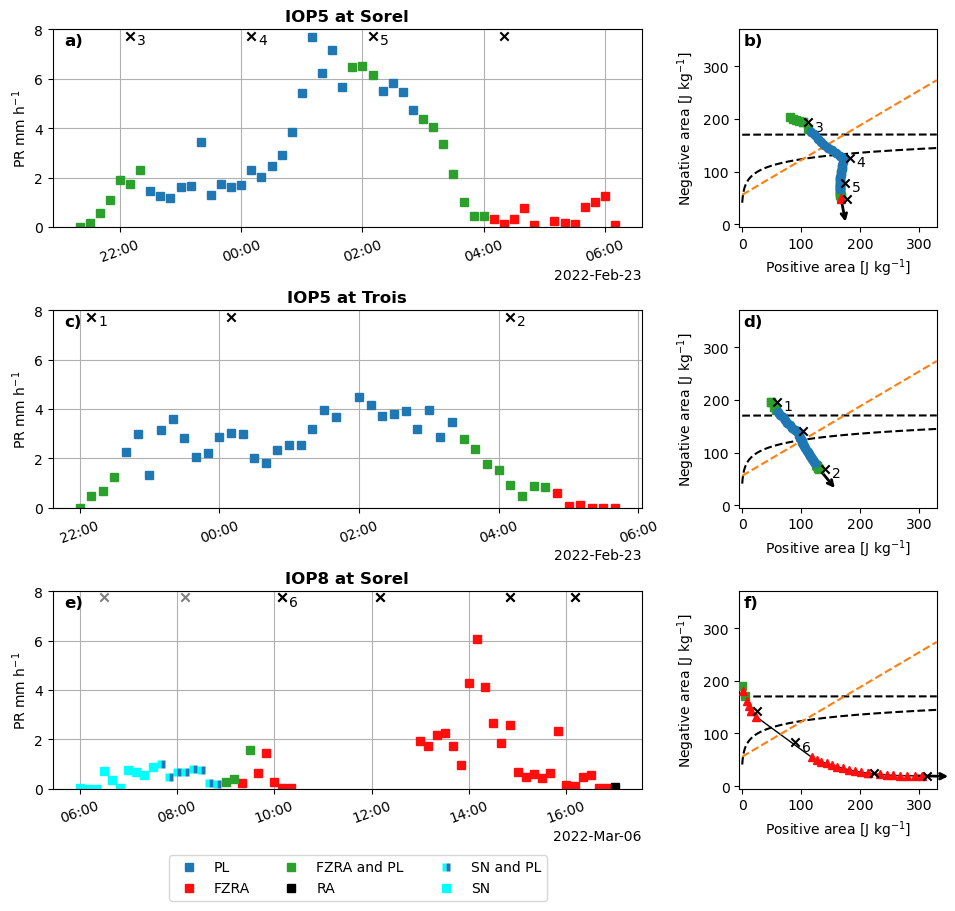

In [ ]:
fig = plt.figure(figsize=(10, 9), constrained_layout=True)
gs = fig.add_gridspec(3, 2, width_ratios=[1.8, 1.0])

ax = np.empty((3, 2), dtype=object)
for i in range(3):
    for j in range(2):
        ax[i, j] = fig.add_subplot(gs[i, j])

# Make right-column panels square
for i in range(3):
    ax[i, 1].set_box_aspect(1)

# Add panel letters at top-left
letters = ["a)", "b)", "c)", "d)", "e)", "f)"]
k = 0
for i in range(3):
    for j in range(2):
        ax[i, j].text(
            0.02, 0.98, letters[k],
            transform=ax[i, j].transAxes,
            ha="left", va="top", fontsize=12, fontweight="bold"
        )
        k += 1



'''
Precipitation rates
'''

color_list = {'SN and FZRA':'blue','SN and RA':'darkblue','None':'grey','No precip.':'grey','PL':'#1f77b4','FZRA':"#ff0e0e",'FZRA and PL':'#2ca02c','RA':'k','SN and PL':'cyan','SN':'cyan','RA and PL':'darkgreen'}
marker_list = {'SN and FZRA':'s','SN and RA':'s','None':'_','No precip.':'_',    'PL':'o'  ,'FZRA':'^','FZRA and PL':'s','SN and FZRA':'s','RA and PL':'s','RA':'^','SN and PL':'o','SN':'o','RA and PL':'s'}
marker_list = {'SN and RA':'s','None':'_','No precip.':'_',    'PL':'s'  ,'FZRA':'s','FZRA and PL':'s','SN and FZRA':'s','RA and PL':'s','RA':'s','SN and PL':'s','SN':'s','RA and PL':'s'}




for v in ['PL','FZRA','FZRA and PL','RA','SN and PL','SN']:#df_manobs.manobs_with_mix.unique()[1:]:
    mask = df_manobs.manobs_with_mix.values == v
    if (v=='FZRA and PL'):
        markerfacecolor    = '#2ca02c'
        markerfacecoloralt = '#2ca02c'
        markeredgecolor    = '#2ca02c'    
    elif ('and' in v):
        markerfacecolor    = color_list[v.split(' ')[0]]
        markerfacecoloralt = color_list[v.split(' ')[-1]]
        markeredgecolor = 'none'
    else:
        markerfacecolor    = color_list[v]
        markerfacecoloralt = color_list[v]
        markeredgecolor    = color_list[v]

    # IOP5 Sorel
    df_for_plot = (df_manobs[mask & (df_manobs.site=='Sorel') & (df_manobs.IOP=='IOP5')])
    ax[0,0].plot(df_for_plot.rounded_time, df_for_plot.pr, markerfacecolor=markerfacecolor,markerfacecoloralt=markerfacecoloralt,marker=marker_list[v],fillstyle='left',linestyle='None',markeredgecolor=markeredgecolor)
    

    # IOP5 Trois
    df_for_plot = (df_manobs[mask & (df_manobs.site=='Trois') & (df_manobs.IOP=='IOP5')])
    ax[1,0].plot(df_for_plot.rounded_time, df_for_plot.pr, markerfacecolor=markerfacecolor,markerfacecoloralt=markerfacecoloralt,marker=marker_list[v],fillstyle='left',linestyle='None',markeredgecolor=markeredgecolor)
    
    # IOP8 Sorel
    df_for_plot = (df_manobs[mask & (df_manobs.site=='Sorel') & (df_manobs.IOP=='IOP8')])
    ax[2,0].plot(df_for_plot.rounded_time, df_for_plot.pr, markerfacecolor=markerfacecolor,markerfacecoloralt=markerfacecoloralt,marker=marker_list[v],fillstyle='left',linestyle='None',markeredgecolor=markeredgecolor,label=v)

# IOP5 Sorel
df_for_plot = (df_manobs[(df_manobs.Sounding==True) & (df_manobs.site=='Sorel') & (df_manobs.IOP=='IOP5')])
ax[0,0].scatter(df_for_plot.rounded_time, 7.75*np.ones(len(df_for_plot.pr)), color='k',marker='x',clip_on=False)
# IOP5 Trois
df_for_plot = (df_manobs[(df_manobs.Sounding==True) &(df_manobs.site=='Trois') & (df_manobs.IOP=='IOP5')])
ax[1,0].scatter(df_for_plot.rounded_time, 7.75*np.ones(len(df_for_plot.pr)), color='k',marker='x',clip_on=False)
# IOP8 Sorel
df_for_plot = (df_manobs[(df_manobs.Sounding==True) &(df_manobs.site=='Sorel') & (df_manobs.IOP=='IOP8')])
ax[2,0].scatter(df_for_plot.rounded_time, 7.75*np.ones(len(df_for_plot.pr)), color='grey',marker='x',clip_on=False)

df_for_plot = (df_manobs[(df_manobs.Sounding==True) & (df_manobs.site=='Sorel') & (df_manobs.IOP=='IOP8')]).iloc[2:]
ax[2,0].scatter(df_for_plot.rounded_time, 7.75*np.ones(len(df_for_plot.pr)), color='k',marker='x',clip_on=False)

# Annotate
df_for_plot = (df_manobs[(df_manobs.Sounding==True) & (df_manobs.site=='Sorel') & (df_manobs.IOP=='IOP5')])
ax[0,0].annotate('3', (df_for_plot.rounded_time.iloc[0], 7.75), textcoords="offset points", xytext=(5,-6), ha='left', fontsize=10)
ax[0,0].annotate('4', (df_for_plot.rounded_time.iloc[1], 7.75), textcoords="offset points", xytext=(5,-6), ha='left', fontsize=10)
ax[0,0].annotate('5', (df_for_plot.rounded_time.iloc[2], 7.75), textcoords="offset points", xytext=(5,-6), ha='left', fontsize=10)
df_for_plot = (df_manobs[(df_manobs.Sounding==True) & (df_manobs.site=='Trois') & (df_manobs.IOP=='IOP5')])
ax[1,0].annotate('1', (df_for_plot.rounded_time.iloc[0], 7.75), textcoords="offset points", xytext=(5,-6), ha='left', fontsize=10)
ax[1,0].annotate('2', (df_for_plot.rounded_time.iloc[2], 7.75), textcoords="offset points", xytext=(5,-6), ha='left', fontsize=10)
df_for_plot = (df_manobs[(df_manobs.Sounding==True) & (df_manobs.site=='Sorel') & (df_manobs.IOP=='IOP8')])
ax[2,0].annotate('6', (df_for_plot.rounded_time.iloc[2], 7.75), textcoords="offset points", xytext=(5,-6), ha='left', fontsize=10)



ax[0,0].set_ylabel(r'PR mm h$^{-1}$')
ax[1,0].set_ylabel(r'PR mm h$^{-1}$')
ax[2,0].set_ylabel(r'PR mm h$^{-1}$')

ax[0,0].set_title('IOP5 at Sorel',weight='bold')
ax[1,0].set_title('IOP5 at Trois',weight='bold')
ax[2,0].set_title('IOP8 at Sorel',weight='bold')

ax[0,0].set_ylim([0, 8])
ax[1,0].set_ylim([0, 8])
ax[2,0].set_ylim([0, 8])

ax[0,0].grid('on')
ax[1,0].grid('on')
ax[2,0].grid('on')

# Improve datetime ticks for precipitation-rate panels (left column)
for r in range(3):
    locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
    formatter = mdates.ConciseDateFormatter(locator)
    formatter.formats = ["%Y", "%b", "%d", "%H:%M", "%H:%M"]
    formatter.zero_formats = ["", "%b", "%b-%d", "%H:%M", "%H:%M"]
    formatter.offset_formats = ["", "%Y", "%Y-%b", "%Y-%b-%d", "%Y-%b-%d %H:%M"]

    ax[r, 0].xaxis.set_major_locator(locator)
    ax[r, 0].xaxis.set_major_formatter(formatter)
    ax[r, 0].tick_params(axis="x", rotation=20)


IOPs = ['IOP5','IOP5','IOP8']
sites = ['Sorel','Trois','Sorel']

for i in range(3):   
    var_to_plot = 'manobs_with_mix'
    df_for_plot = (df_manobs[(df_manobs.site==sites[i]) & (df_manobs.IOP==IOPs[i])])
    if (((df_for_plot.CL_integral<0.) & (df_for_plot.WL_integral>0.) ).any()):#  & \

        fig,ax[i,1] = plot_trajectory(fig,ax[i,1],df_for_plot,var_to_plot = var_to_plot)

        ax[i,1].scatter(df_for_plot[df_for_plot.Sounding==True].WL_integral*grav/273.15+10,-df_for_plot[df_for_plot.Sounding==True].CL_integral*grav/273.15,marker='x',color='k',zorder=100)
        

        
        ax[i,1].set_ylim([-5,370])
        ax[i,1].set_xlim([-5,330])
        i=i+1



# Annotate
df_for_plot = df_manobs[(df_manobs.Sounding==True) & (df_manobs.site=='Sorel') & (df_manobs.IOP=='IOP5')].iloc[0]
ax[0,1].annotate('3', (df_for_plot.WL_integral*grav/273.15+10,-df_for_plot.CL_integral*grav/273.15), textcoords="offset points", xytext=(5,-6), ha='left', fontsize=10)
df_for_plot = df_manobs[(df_manobs.Sounding==True) & (df_manobs.site=='Sorel') & (df_manobs.IOP=='IOP5')].iloc[1]
ax[0,1].annotate('4', (df_for_plot.WL_integral*grav/273.15+10,-df_for_plot.CL_integral*grav/273.15), textcoords="offset points", xytext=(5,-6), ha='left', fontsize=10)
df_for_plot = df_manobs[(df_manobs.Sounding==True) & (df_manobs.site=='Sorel') & (df_manobs.IOP=='IOP5')].iloc[2]
ax[0,1].annotate('5', (df_for_plot.WL_integral*grav/273.15+10,-df_for_plot.CL_integral*grav/273.15), textcoords="offset points", xytext=(5,-6), ha='left', fontsize=10)
df_for_plot = df_manobs[(df_manobs.Sounding==True) & (df_manobs.site=='Trois') & (df_manobs.IOP=='IOP5')].iloc[0]
ax[1,1].annotate('1', (df_for_plot.WL_integral*grav/273.15+10,-df_for_plot.CL_integral*grav/273.15), textcoords="offset points", xytext=(5,-6), ha='left', fontsize=10)
df_for_plot = df_manobs[(df_manobs.Sounding==True) & (df_manobs.site=='Trois') & (df_manobs.IOP=='IOP5')].iloc[2]
ax[1,1].annotate('2', (df_for_plot.WL_integral*grav/273.15+10,-df_for_plot.CL_integral*grav/273.15), textcoords="offset points", xytext=(5,-6), ha='left', fontsize=10)
df_for_plot = df_manobs[(df_manobs.Sounding==True) & (df_manobs.site=='Sorel') & (df_manobs.IOP=='IOP8')].iloc[3]
ax[2,1].annotate('6', (df_for_plot.WL_integral*grav/273.15+10,-df_for_plot.CL_integral*grav/273.15), textcoords="offset points", xytext=(5,-6), ha='left', fontsize=10)


ax[2,0].legend(loc='upper right',bbox_to_anchor=(0.85,-0.3), ncol=3)

# plt.savefig('figures/pcprate_traj_wintremix.png',bbox_inches='tight')
plt.show()